# Análise Exploratória Inicial

In [1]:
import warnings

import duckdb
import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import FactorAnalysis
from factor_analyzer.factor_analyzer import (
    FactorAnalyzer,
    calculate_kmo,
    calculate_bartlett_sphericity,
)


sns.set_style('dark')
sns.set_palette('deep')
warnings.filterwarnings('ignore')

In [2]:
df_xrf = duckdb.read_csv('../XRF_library.csv').df()
df_xrf.drop(columns=['year', 'sample'], inplace=True)
df_xrf.set_index('Area', inplace=True)
df_xrf.sort_index(inplace=True)

targets = ['SOC', 'exCa', 'exMg', 'exK', 'SB']
all_features = [col for col in df_xrf.columns if col not in targets]
soil_features = all_features[:4]  # Features solo
spectral_features = all_features[4:]  # Features espectrais

print(f'{targets=}')
print(f'{soil_features=}')
print(f'spectral_features={spectral_features[:3]} ... {spectral_features[-3:]}')

df_xrf

targets=['SOC', 'exCa', 'exMg', 'exK', 'SB']
soil_features=['pH', 'H+Al', 'Pav', 'CEC']
spectral_features=['1', '1.02', '1.04'] ... ['14.96', '14.98', '15']


,SOC,pH,H+Al,Pav,exCa,exMg,exK,SB,CEC,1,...,14.82,14.84,14.86,14.88,14.9,14.92,14.94,14.96,14.98,15
Area,,,,,,,,,,,,,,,,,,,,,
Cambe,18.89,5.2,5.34,24.20,4.32,1.68,0.56,6.56,11.90,0.134800,...,0.024005,0.016618,0.025853,0.007387,0.011079,0.014771,0.012924,0.007386,0.016618,0.024004
Cambe,16.71,5.0,5.76,2.70,5.52,1.39,0.41,7.32,13.08,0.112330,...,0.021307,0.016551,0.014218,0.018900,0.014228,0.014183,0.009428,0.008300,0.013016,0.010653
Cambe,21.31,5.3,5.34,9.70,7.60,2.05,0.50,10.15,15.49,0.135350,...,0.013291,0.016918,0.015707,0.015706,0.015709,0.012083,0.012083,0.012083,0.007249,0.010877
Cambe,18.42,5.2,5.76,4.50,7.20,1.80,0.38,9.38,15.14,0.144170,...,0.023200,0.010966,0.013471,0.019517,0.012210,0.012217,0.019538,0.014661,0.014642,0.013412
Cambe,16.79,5.2,5.34,1.20,7.67,1.48,0.33,9.48,14.82,0.113520,...,0.024675,0.019731,0.023445,0.012337,0.020978,0.012337,0.017276,0.012349,0.023445,0.011099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Toledo,16.21,5.7,3.69,3.77,6.20,3.21,0.62,10.03,13.72,0.150000,...,0.020000,0.020000,0.015000,0.020000,0.015000,0.010000,0.015000,0.020000,0.020000,0.010000
Toledo,20.45,5.9,3.18,28.49,7.83,3.78,0.62,12.23,15.41,0.135000,...,0.025000,0.020000,0.015000,0.010000,0.020000,0.005000,0.010000,0.010000,0.015000,0.005000
Toledo,24.04,6.2,2.95,21.58,3.18,0.78,0.65,4.60,7.55,0.130000,...,0.015000,0.010000,0.025000,0.010000,0.020000,0.015000,0.020000,0.015000,0.015000,0.010000


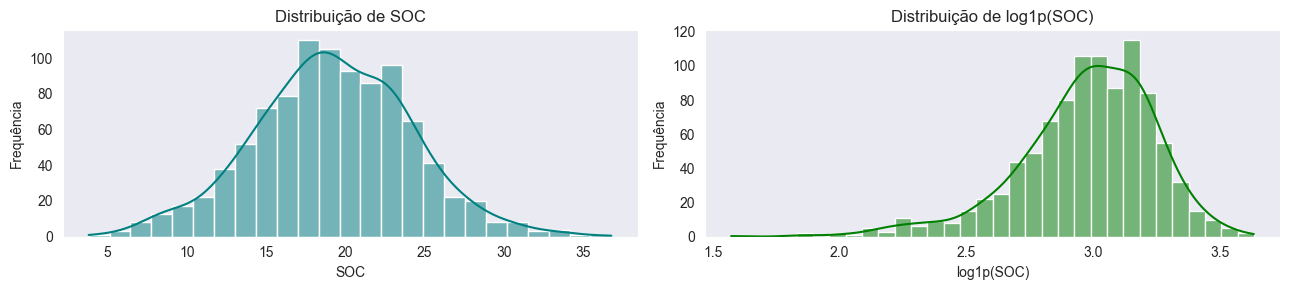

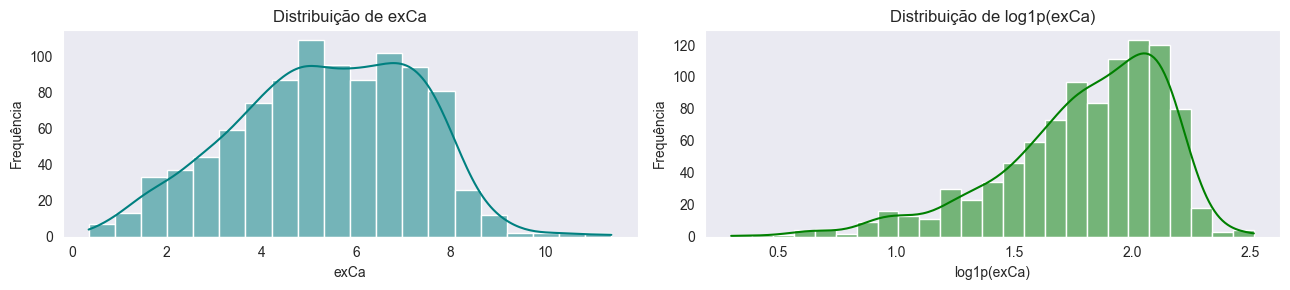

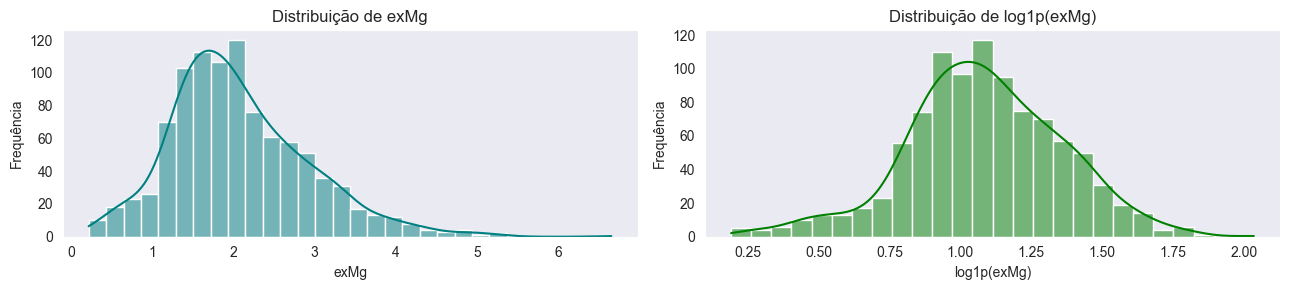

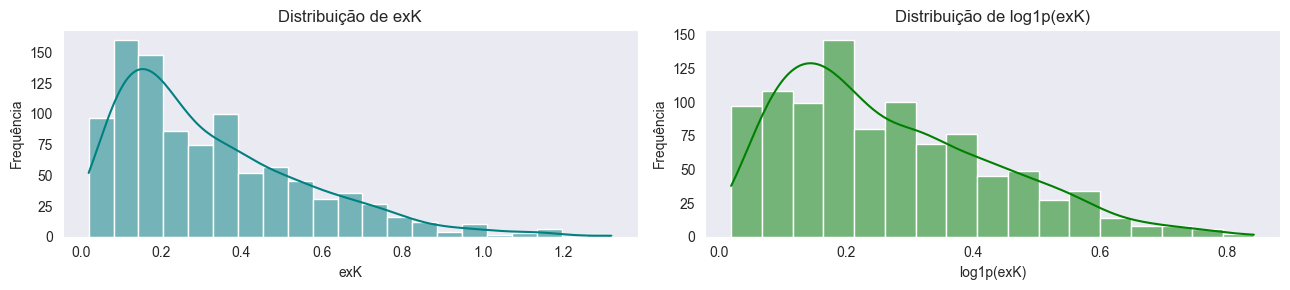

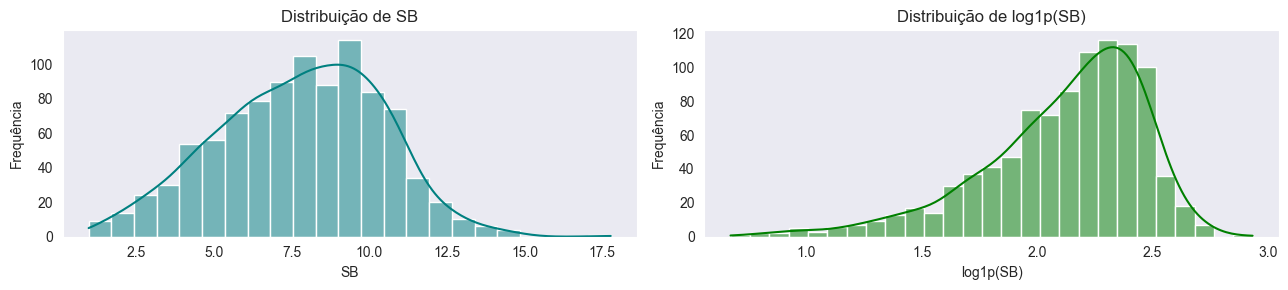

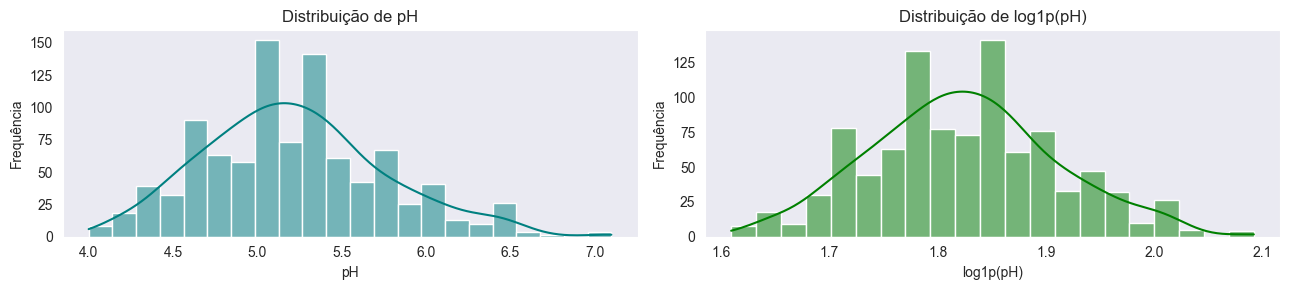

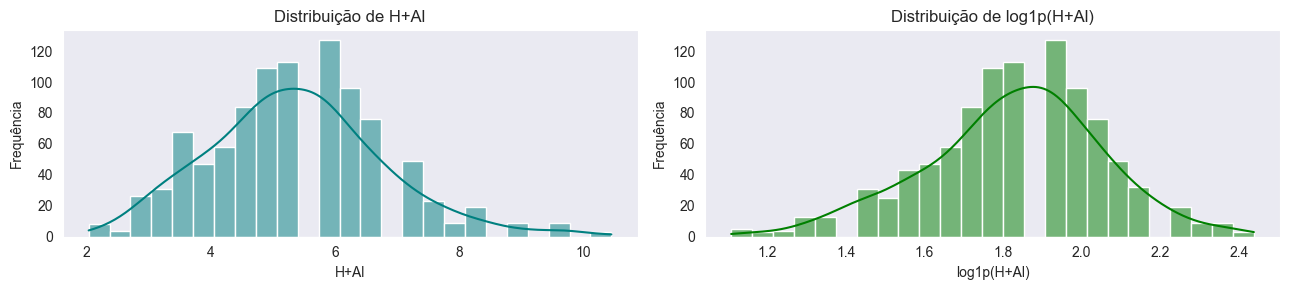

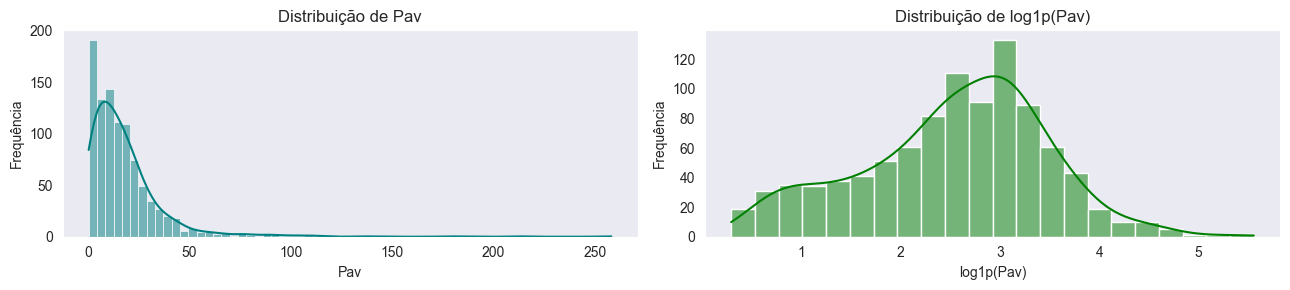

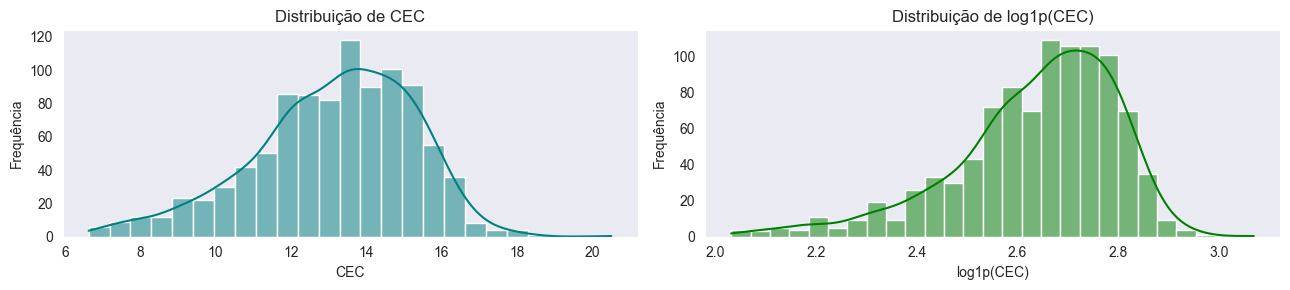

In [3]:
# Criar gráficos separados para cada variável (histograma, log1p histograma, boxplot)
for column in [*targets, *soil_features]:
    plt.figure(figsize=(13, 3))
    
    # Subplot 1 - Histograma + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df_xrf[column], bins='auto', kde=True, color='teal')
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    
    # Subplot 2 - Histograma log1p + KDE
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df_xrf[column]), bins='auto', kde=True, color='green')
    plt.title(f'Distribuição de log1p({column})')
    plt.xlabel(f'log1p({column})')
    plt.ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()
    plt.close()

<Axes: >

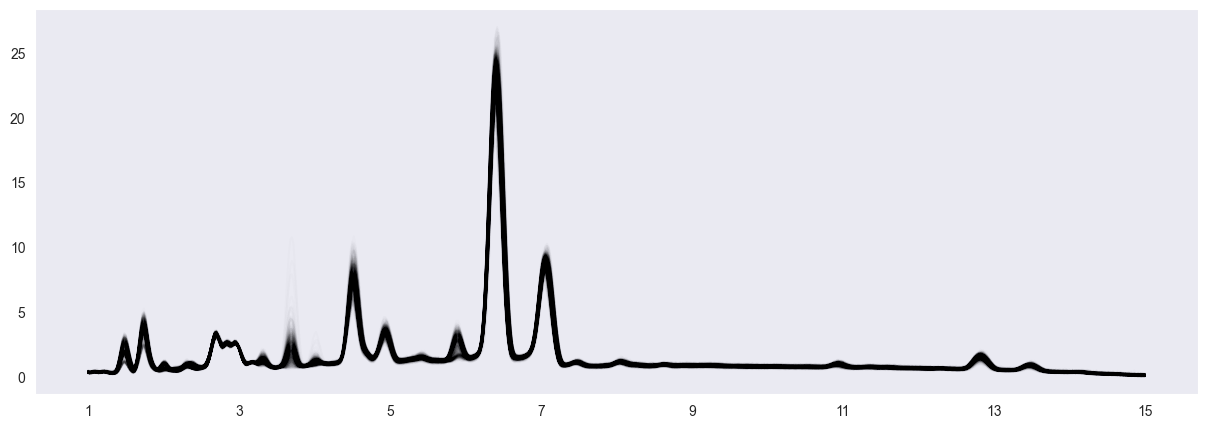

In [4]:
df_xrf[spectral_features].apply(lambda x: x/np.sqrt(x.mean())).T.plot(legend=False, figsize=(15, 5), color='k', alpha=0.01)

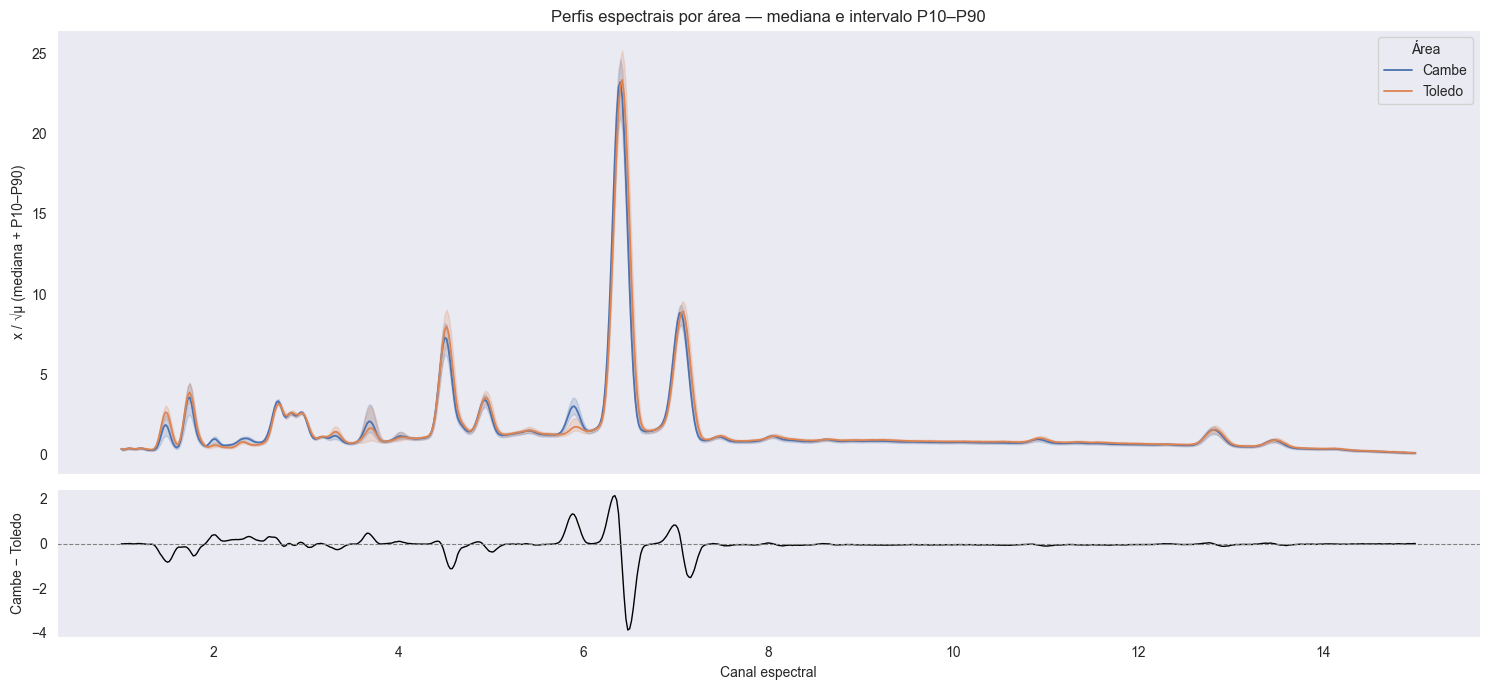

In [5]:
X_scaled = df_xrf[spectral_features].apply(lambda x: x / np.sqrt(x.mean()), axis=0)

areas = df_xrf.index.unique()
palette = dict(zip(areas, sns.color_palette('deep', n_colors=len(areas))))
x = [float(c) for c in spectral_features]  # eixo x numérico (canal espectral)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

medians = {}
for area in areas:
    sub = X_scaled.loc[area]
    median = sub.median(axis=0)
    p10 = sub.quantile(0.10, axis=0)
    p90 = sub.quantile(0.90, axis=0)
    medians[area] = median

    ax1.plot(x, median.values, color=palette[area], label=area, linewidth=1.3)
    ax1.fill_between(x, p10.values, p90.values, color=palette[area], alpha=0.2)

ax1.set_ylabel('x / √μ (mediana + P10–P90)')
ax1.set_title('Perfis espectrais por área — mediana e intervalo P10–P90')
ax1.legend(title='Área')

# painel de diferença entre as duas áreas
area1, area2 = areas[0], areas[1]
diff = medians[area1] - medians[area2]
ax2.plot(x, diff.values, color='black', linewidth=1)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel(f'{area1} − {area2}')
ax2.set_xlabel('Canal espectral')

plt.tight_layout()
plt.show()
plt.close()

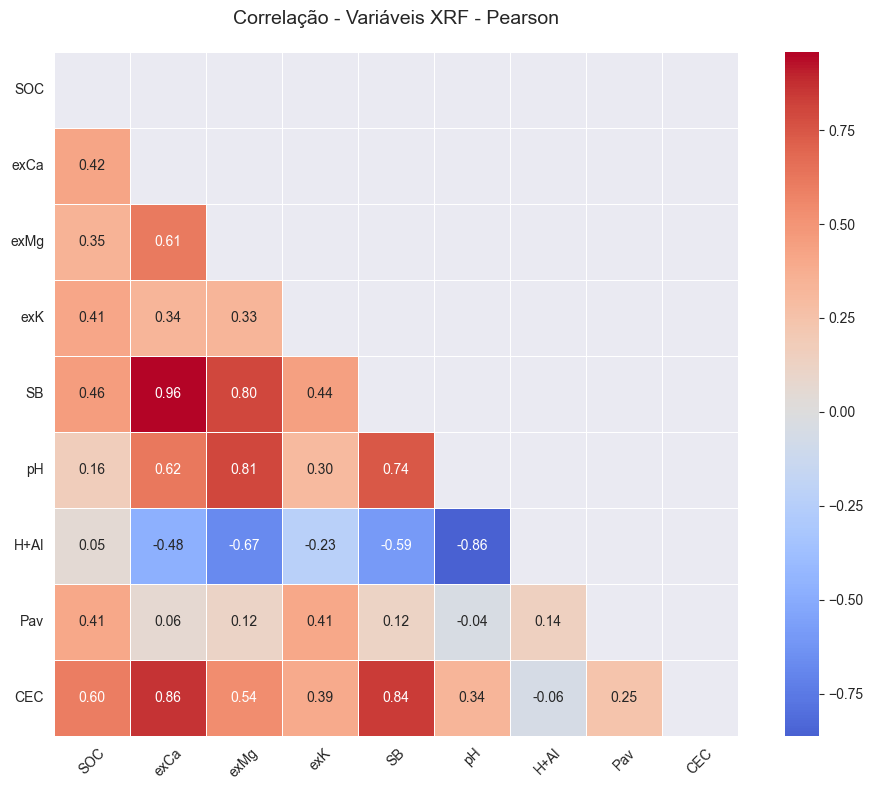

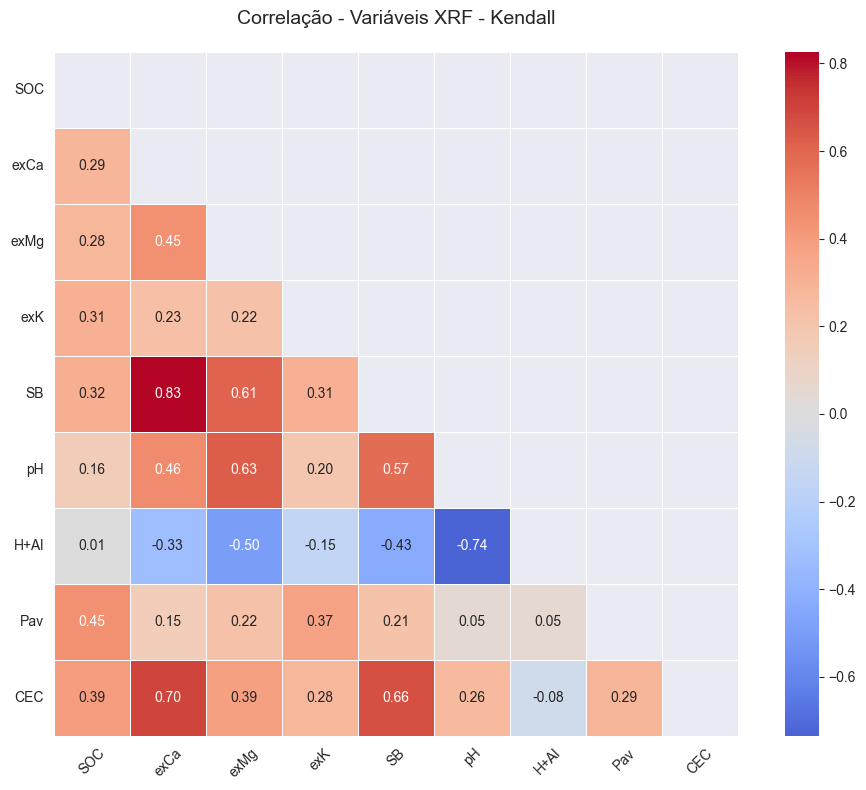

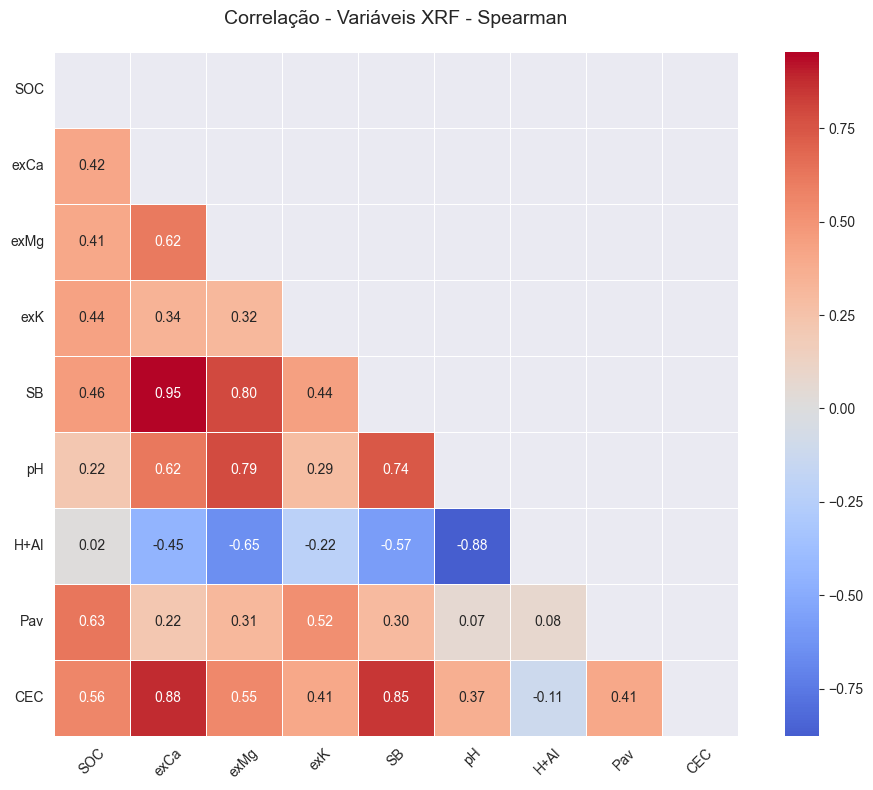

In [6]:
for corr_method in ['pearson', 'kendall', 'spearman']:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = df_xrf[targets + soil_features].corr(method=corr_method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title(f'Correlação - Variáveis XRF - {corr_method.capitalize()}', fontsize=14, pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    plt.close()

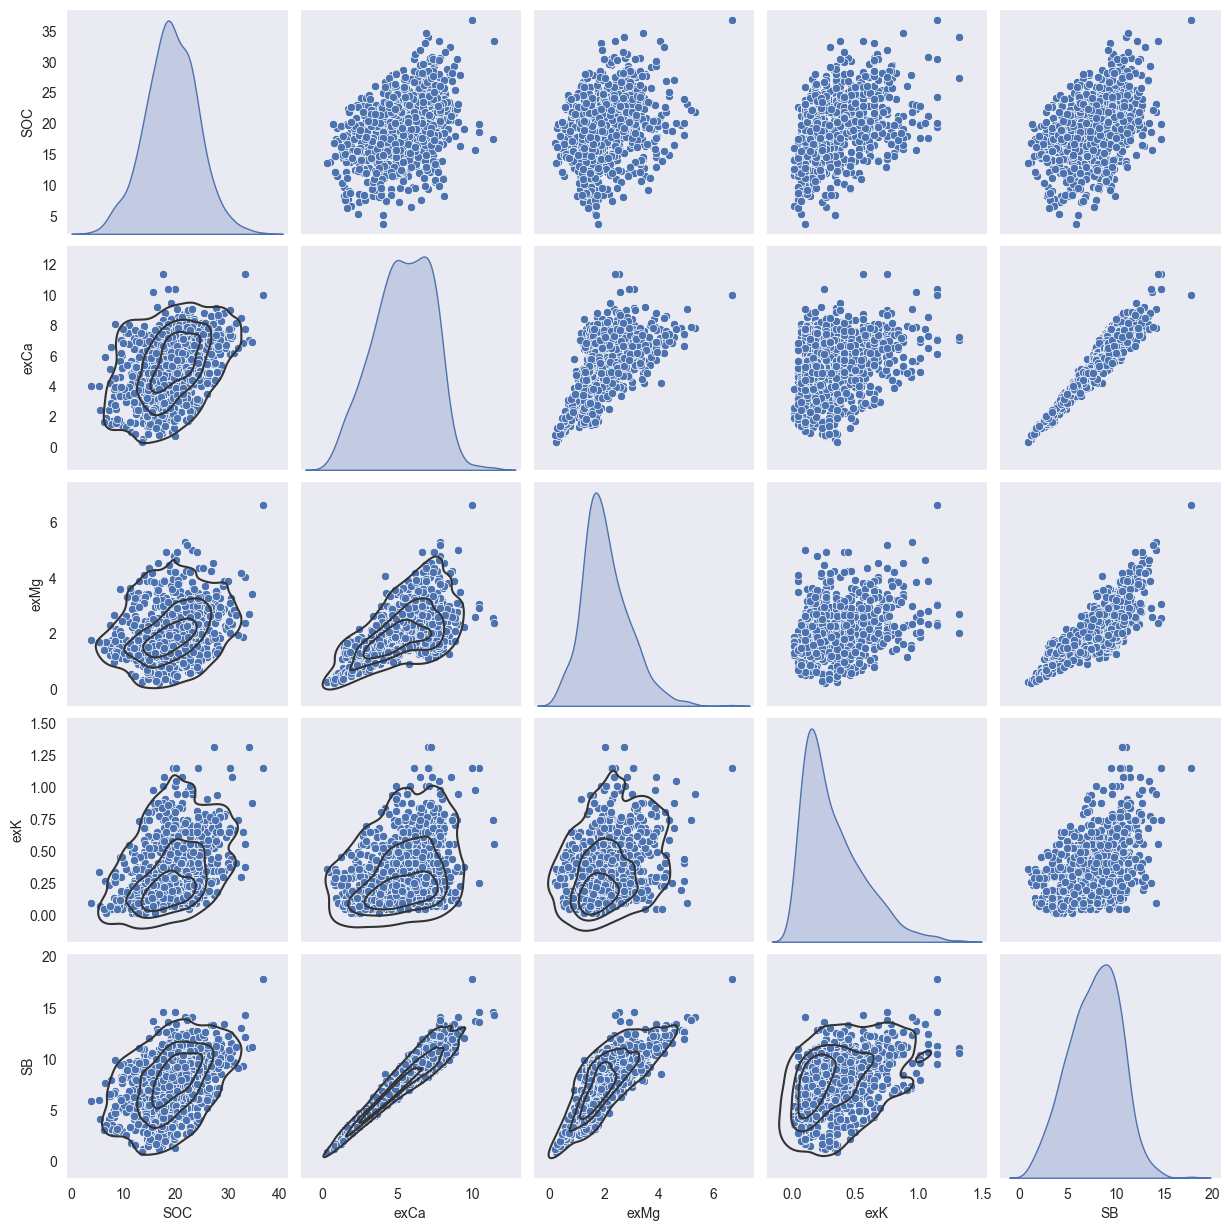

In [7]:
(
    sns.pairplot(df_xrf[targets], diag_kind="kde")
    .map_lower(sns.kdeplot, levels=4, color=".2")
)

In [8]:
def analise_estatistica_descritiva(grupo_valores):
    # Estatísticas descritivas
    stats_data = []
    for grupo, valores in grupo_valores.items():
        stats_data.append({
            'Área': grupo,
            'Média': valores.mean(),
            'Mediana': np.median(valores),
            'Desv. P': valores.std(ddof=1),
            'N': len(valores),
            'IQR': np.percentile(valores, 75) - np.percentile(valores, 25)
        })
    df_stats = pd.DataFrame(stats_data)
    display(df_stats.style.format(precision=3))
    print('\n' + '='*60)

    # Realizar Teste de Kolmogorov-Smirnov
    alpha = 0.05
    stat_ks, pvalue_ks = stats.ks_2samp(*grupo_valores.values())
    interp = 'Diferentes' if pvalue_ks < alpha else 'Iguais'

    print("Teste de Kolmogorov-Smirnov para duas amostras independentes")
    print(f"P-valor: {pvalue_ks:.4f}")
    print(f"Estatística: {stat_ks:.4f}")
    print(f"As distribuições são {interp}.")
    
    # Interpretar resultados
    if pvalue_ks < alpha:
        print(f"\nConclusão: Rejeitar H₀ (p < {alpha})")
        print("Há uma diferença significativa entre as distribuições dos grupos.")
        print("As amostras não vêm da mesma distribuição.")
    else:
        print(f"\nConclusão: Não rejeitar H₀ (p ≥ {alpha})")
        print("Não há diferença significativa entre as distribuições dos grupos.")
        print("As amostras podem vir da mesma distribuição.")

    print('\n' + '='*60)
    print("Testes Complementares")
    
    # Teste U de Mann-Whitney
    stat_mw, pvalue_mw = stats.mannwhitneyu(*grupo_valores.values())
    interp = 'Diferentes' if pvalue_mw < alpha else 'Iguais'
    print(f"{'Mann-Whitney U:':<28} P-valor = {pvalue_mw:.4f}, {interp}, Estatística = {stat_mw:.4f}")
        
    # Teste T de Student para amostras independentes
    stat_t, pvalue_t = stats.ttest_ind(*grupo_valores.values(), equal_var=False)
    interp = 'Diferentes' if pvalue_t < alpha else 'Iguais'
    print(f"{'T de Student (Welch):':<28} P-valor = {pvalue_t:.4f}, {interp}, Estatística = {stat_t:.4f}")

    # Teste de Baumgartner-Weiss-Schindler
    res_bws = stats.bws_test(*grupo_valores.values())
    stat_bm, pvalue_bm = res_bws.statistic, res_bws.pvalue
    interp = 'Diferentes' if pvalue_bm < alpha else 'Iguais'
    print(f"{'Baumgartner-Weiss-Schindler:':<28} P-valor = {pvalue_bm:.4f}, {interp}, Estatística = {stat_bm:.4f}")

Variável: SOC


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,19.347,19.260,4.080,614,5.950
1,Toledo,18.988,18.970,6.203,354,8.122



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0007
Estatística: 0.1320
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.2191, Iguais, Estatística = 113827.0000
T de Student (Welch):        P-valor = 0.3306, Iguais, Estatística = 0.9739
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 12.4254


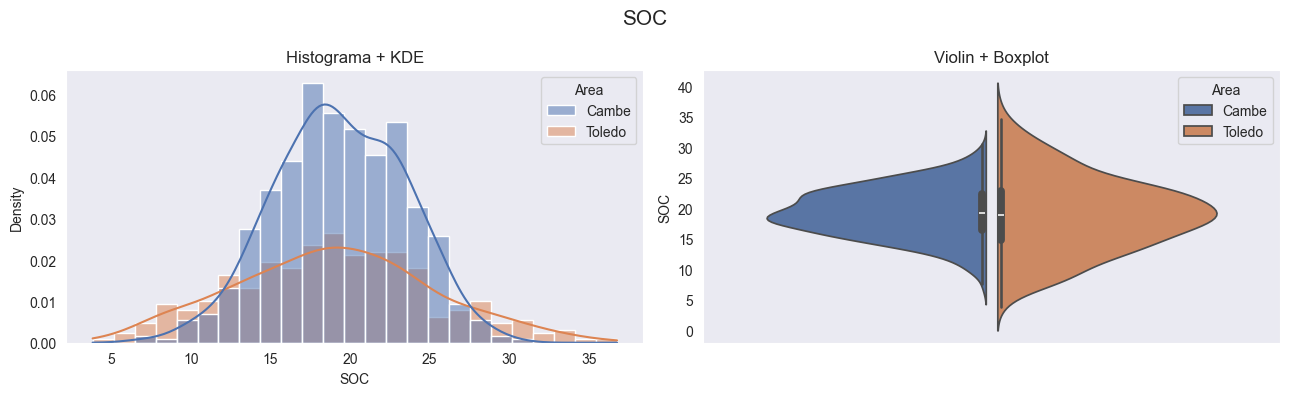

Variável: exCa


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,5.858,5.950,1.622,614,2.415
1,Toledo,4.527,4.425,2.081,354,3.388



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.3050
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0000, Diferentes, Estatística = 150039.0000
T de Student (Welch):        P-valor = 0.0000, Diferentes, Estatística = 10.3573
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 62.3150


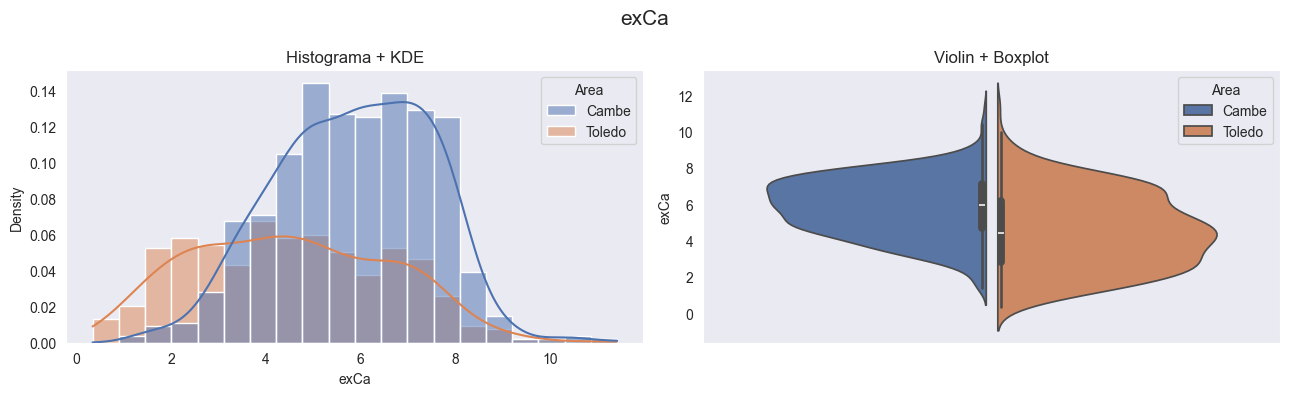

Variável: exMg


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,2.029,1.930,0.613,614,0.860
1,Toledo,2.134,1.890,1.166,354,1.728



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.2059
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.5926, Iguais, Estatística = 110920.0000
T de Student (Welch):        P-valor = 0.1166, Iguais, Estatística = -1.5721
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 35.2876


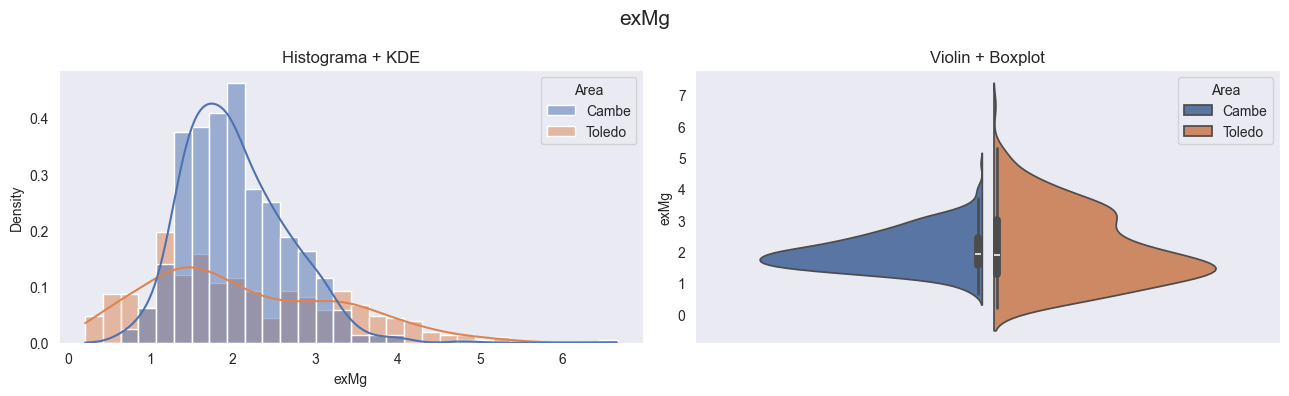

Variável: exK


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,0.292,0.230,0.211,614,0.240
1,Toledo,0.386,0.360,0.266,354,0.390



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.2349
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0000, Diferentes, Estatística = 87100.0000
T de Student (Welch):        P-valor = 0.0000, Diferentes, Estatística = -5.7251
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 23.4004


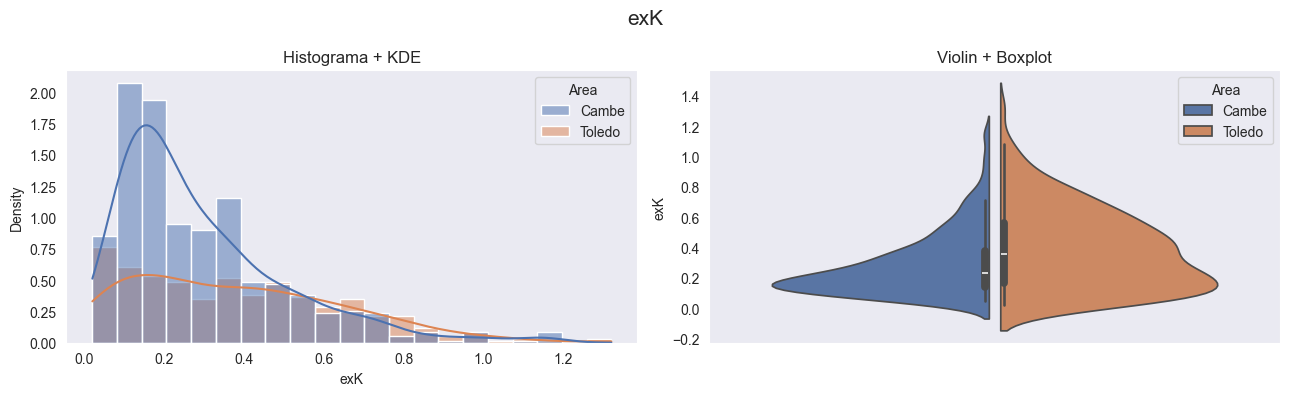

Variável: SB


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,8.179,8.290,2.083,614,2.910
1,Toledo,7.045,6.690,3.247,354,5.258



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.2769
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0000, Diferentes, Estatística = 134100.5000
T de Student (Welch):        P-valor = 0.0000, Diferentes, Estatística = 5.9055
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 43.1135


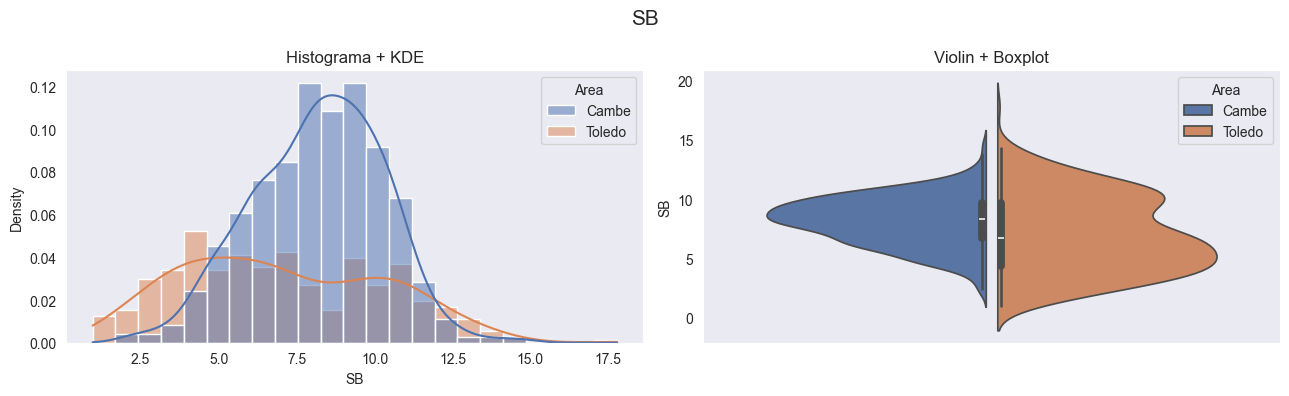

Variável: pH


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,5.187,5.200,0.442,614,0.600
1,Toledo,5.276,5.250,0.678,354,1.000



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0002
Estatística: 0.1432
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.1554, Iguais, Estatística = 102736.0000
T de Student (Welch):        P-valor = 0.0271, Diferentes, Estatística = -2.2165
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 18.9393


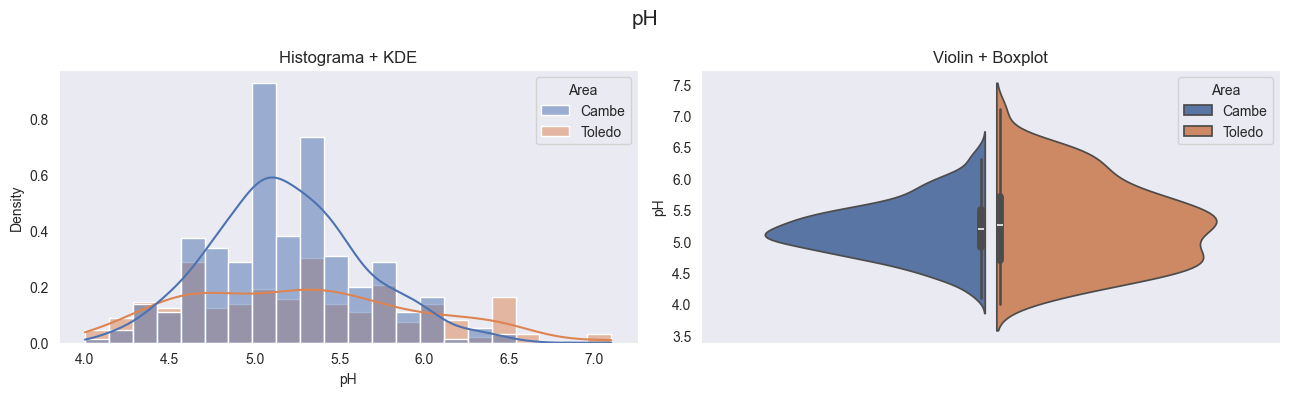

Variável: H+Al


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,5.555,5.340,1.173,614,1.240
1,Toledo,5.064,4.960,1.744,354,2.517



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.2828
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0000, Diferentes, Estatística = 132329.5000
T de Student (Welch):        P-valor = 0.0000, Diferentes, Estatística = 4.7150
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 41.1976


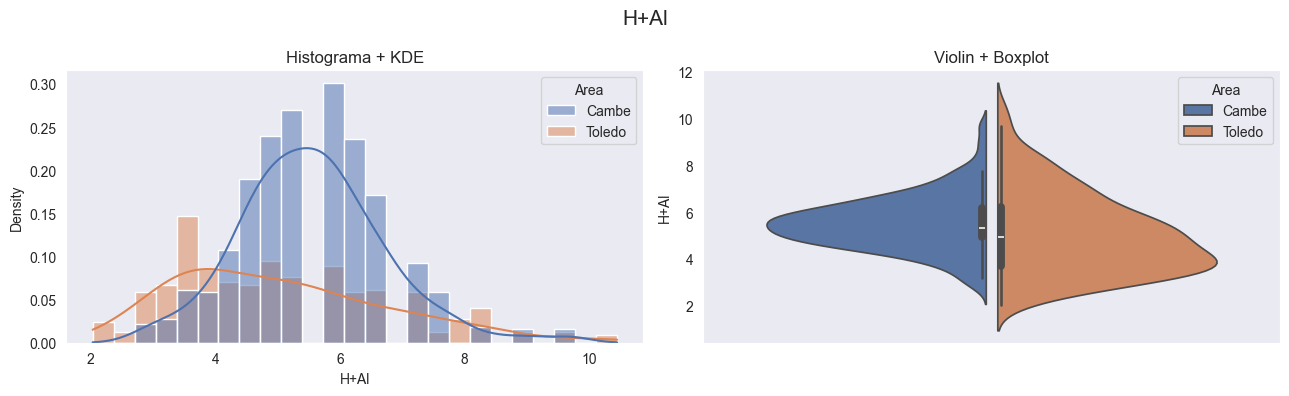

Variável: Pav


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,16.609,13.800,12.269,614,13.675
1,Toledo,20.137,10.205,29.199,354,23.203



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.2268
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0012, Diferentes, Estatística = 122240.0000
T de Student (Welch):        P-valor = 0.0309, Diferentes, Estatística = -2.1654
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 26.5207


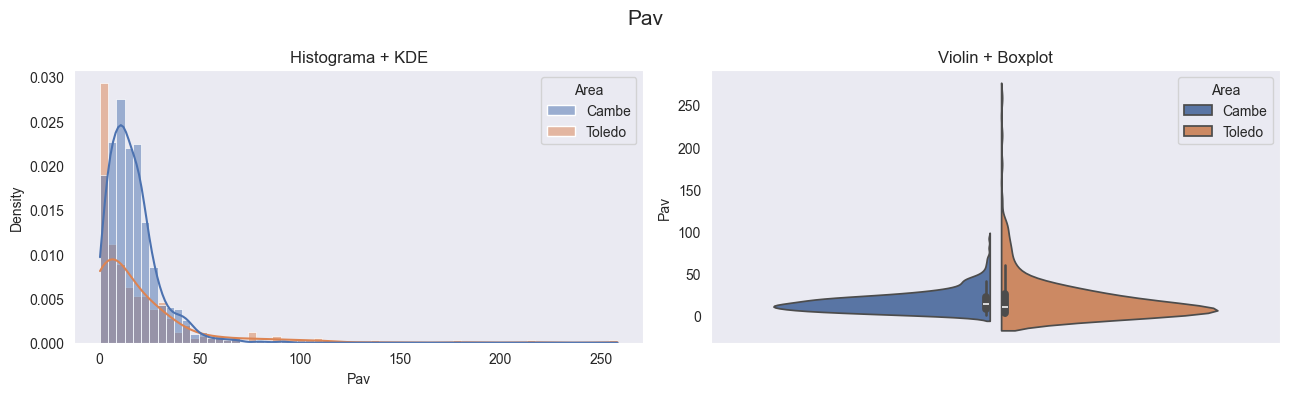

Variável: CEC


,Área,Média,Mediana,Desv. P,N,IQR
0,Cambe,13.733,13.730,1.529,614,2.318
1,Toledo,12.109,12.020,2.573,354,3.875



Teste de Kolmogorov-Smirnov para duas amostras independentes
P-valor: 0.0000
Estatística: 0.3667
As distribuições são Diferentes.

Conclusão: Rejeitar H₀ (p < 0.05)
Há uma diferença significativa entre as distribuições dos grupos.
As amostras não vêm da mesma distribuição.

Testes Complementares
Mann-Whitney U:              P-valor = 0.0000, Diferentes, Estatística = 150558.5000
T de Student (Welch):        P-valor = 0.0000, Diferentes, Estatística = 10.8291
Baumgartner-Weiss-Schindler: P-valor = 0.0001, Diferentes, Estatística = 90.2008


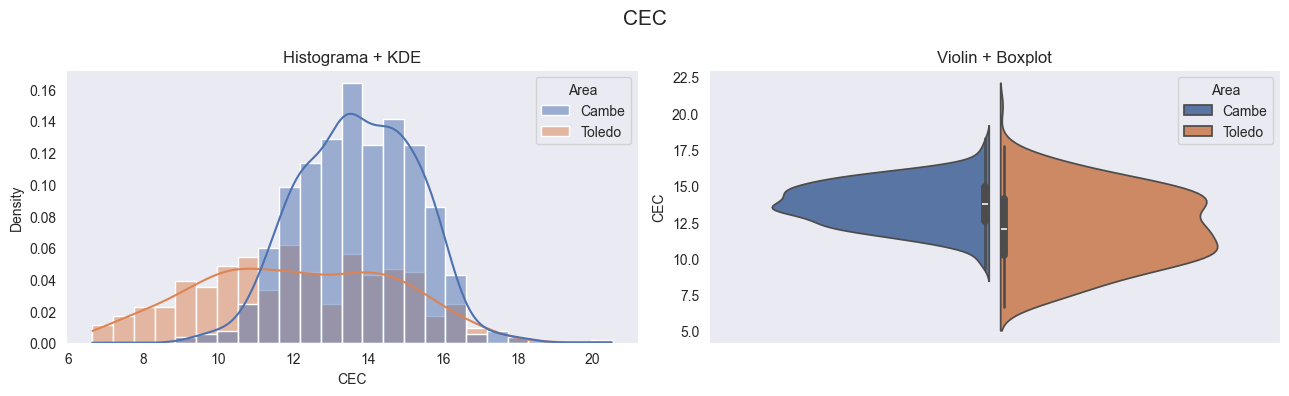

In [9]:
# Criar gráficos separados para cada variável (histograma+kde, violin+boxplot)
for column in [*targets, *soil_features]:
    print('Variável:', column)
    grupo_valores = df_xrf.groupby('Area')[column].apply(np.array).to_dict()
    analise_estatistica_descritiva(grupo_valores)

    plt.figure(figsize=(13, 4))
    plt.suptitle(column, size=15)
    
    # Subplot 1 - Histograma + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df_xrf, x=column, hue='Area', bins='auto', stat='density', kde=True)
    plt.title('Histograma + KDE')
    
    # Subplot 2 - Violin + Boxplot 
    plt.subplot(1, 2, 2)
    sns.violinplot(df_xrf, y=column, hue='Area', split=True, gap=0.05)
    plt.title('Violin + Boxplot')
    
    plt.tight_layout()
    plt.show()
    plt.close()

## Verifica Poisson Scaling

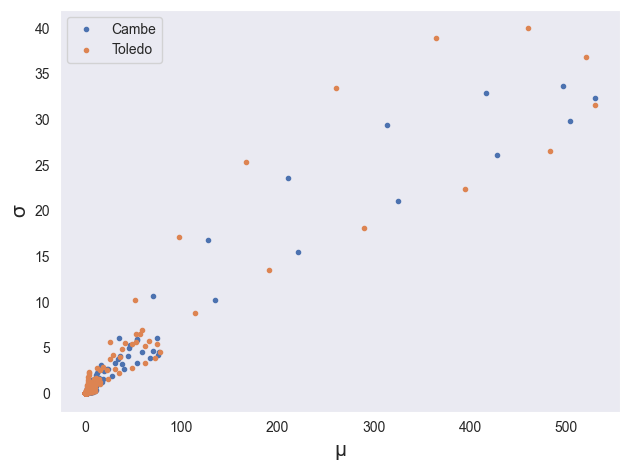

In [10]:
fig, ax = plt.subplots()

for area in df_xrf.index.unique():
    x = []
    y = []
    for column in spectral_features:
        x.append(
            df_xrf.loc[area, column].mean()
        )
        y.append(
            df_xrf.loc[area, column].std()
        )

    ax.plot(x, y, '.', label=area)

ax.set_xlabel('μ', size=15)
ax.set_ylabel('σ', size=15)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

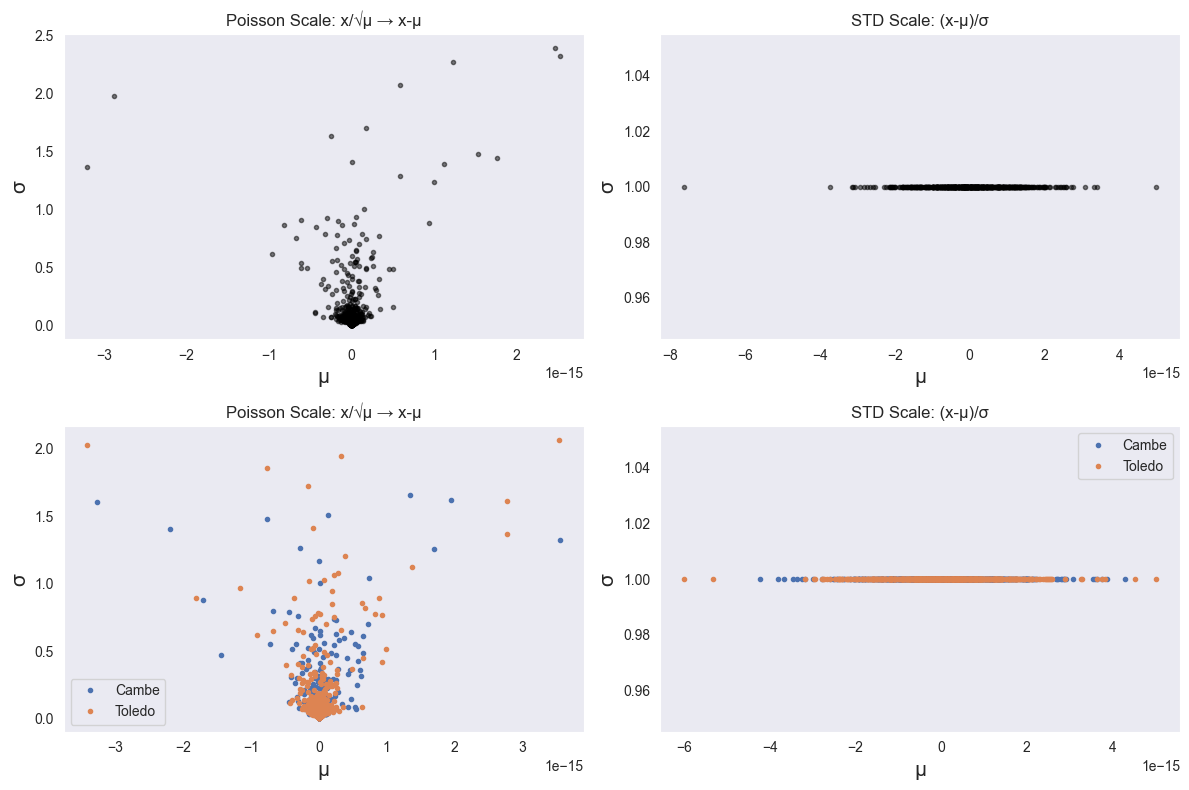

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Poisson Scale
x = []
y = []
for column in spectral_features:
    v = df_xrf.loc[:, column].to_numpy()
    v_ = v / (v.mean()+1)**.5
    v_ -= v_.mean()

    x.append(v_.mean())
    y.append(v_.std())

ax1.plot(x, y, '.k', alpha=0.5)
ax1.set_title('Poisson Scale: x/√μ → x-μ')
ax1.set_xlabel('μ', size=15)
ax1.set_ylabel('σ', size=15)

# Std Scale
x = []
y = []
for column in spectral_features:
    v = df_xrf.loc[:, column].to_numpy()
    v_ = (v - v.mean()) / v.std()

    x.append(v_.mean())
    y.append(v_.std())

ax2.plot(x, y, '.k', alpha=0.5)
ax2.set_title('STD Scale: (x-μ)/σ')
ax2.set_xlabel('μ', size=15)
ax2.set_ylabel('σ', size=15)


# Poisson Scale
for area in df_xrf.index.unique():
    x = []
    y = []
    for column in spectral_features:
        v = df_xrf.loc[area, column].to_numpy()
        v_ = v / (v.mean()+1)**.5
        v_ -= v_.mean()

        x.append(v_.mean())
        y.append(v_.std())

    ax3.plot(x, y, '.', label=area)
ax3.set_title('Poisson Scale: x/√μ → x-μ')
ax3.set_xlabel('μ', size=15)
ax3.set_ylabel('σ', size=15)
ax3.legend()

# Std Scale
for area in df_xrf.index.unique():
    x = []
    y = []
    for column in spectral_features:
        v = df_xrf.loc[area, column].to_numpy()
        v_ = (v - v.mean()) / v.std()

        x.append(v_.mean())
        y.append(v_.std())

    ax4.plot(x, y, '.', label=area)
ax4.set_title('STD Scale: (x-μ)/σ')
ax4.set_xlabel('μ', size=15)
ax4.set_ylabel('σ', size=15)
ax4.legend()

plt.tight_layout()
plt.show()
plt.close()

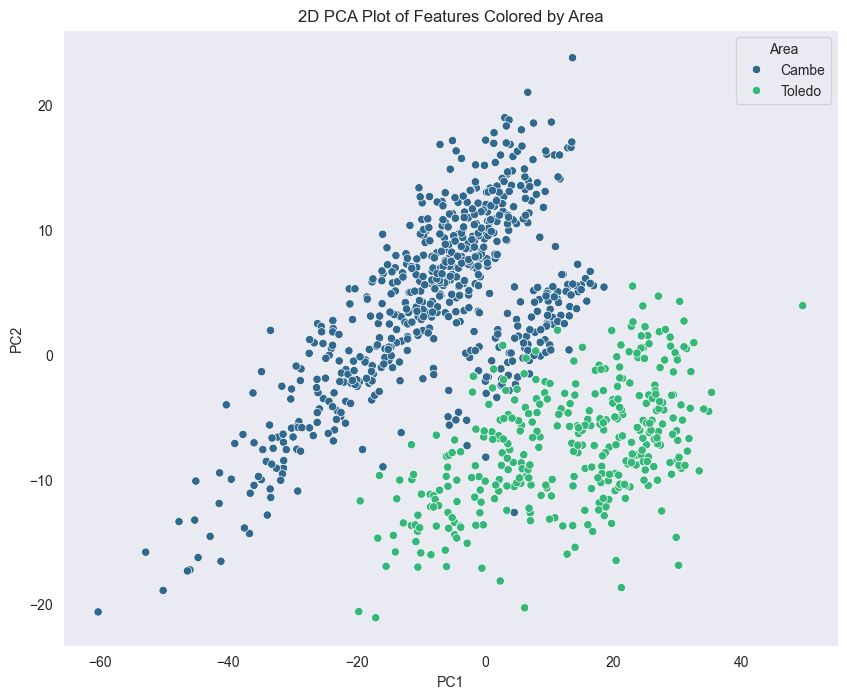

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = df_xrf[spectral_features]
X_scaled = StandardScaler().fit_transform(X) 

# Perform PCA on the spectral features
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=df_xrf.index)

# Plot the 2D PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=pca_df.index, palette='viridis')
plt.title('2D PCA Plot of Features Colored by Area')
plt.legend(title='Area')
plt.show()
plt.close()

# Testar adequação para Análise Fatorial 

## Critério de Kaiser-Meyer-Olkin

O Critério de Kaiser-Meyer-Olkin (KMO) é um índice que avalia a adequação da amostra para a Análise Fatorial.<br>
Ele compara a magnitude dos coeficientes de correlação observados com a magnitude dos coeficientes de correlação parcial.

* Varia de 0 a 1.
* KMO próximo de 1: indica que as correlações entre as variáveis são explicáveis por fatores comuns, sendo adequado para análise fatorial.
* KMO abaixo de 0.5: considera-se inadequado; valores acima de 0,7 são aceitáveis, e acima de 0,8 são bons.

Em resumo, o KMO mede se os dados são apropriados para reduzir dimensões via análise fatorial

KMO total: 0.9788


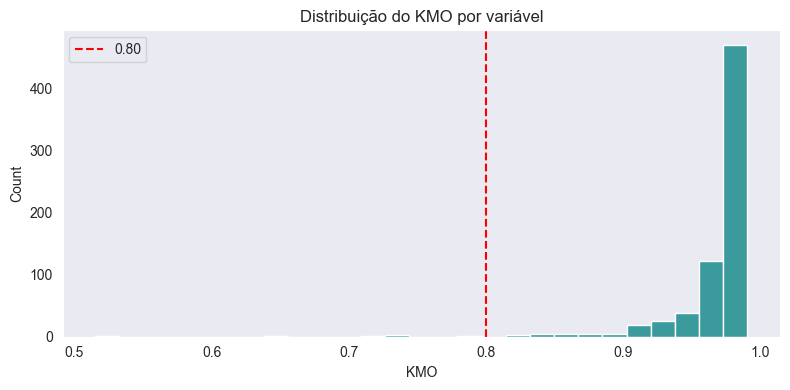

In [17]:
X = df_xrf[spectral_features].to_numpy()
kmo_per_variable, kmo_total = calculate_kmo(X)

print(f'KMO total: {kmo_total:.4f}')
plt.figure(figsize=(8, 4))
sns.histplot(kmo_per_variable, bins='sqrt', color='teal')
plt.axvline(0.8, color='red', linestyle='--', label='0.80')
plt.title('Distribuição do KMO por variável')
plt.xlabel('KMO')
plt.legend()
plt.tight_layout()
plt.show()

## Teste de Esfericidade de Bartlett

O Teste de Esfericidade de Bartlett verifica se a matriz de correlações das variáveis é uma matriz identidade (ou seja, se as correlações entre as variáveis são nulas).

* Hipótese nula (H₀): a matriz de correlações é uma matriz identidade (não há correlações significativas entre as variáveis).
* Objetivo: rejeitar H₀ para justificar a aplicação de análise fatorial/análise de componentes principais.
* Interpretação: um valor-p baixo (geralmente < 0,05) indica que há correlações significativas entre pelo menos algumas variáveis, tornando os dados adequados para a análise fatorial.

Em resumo, o teste avalia se existe estrutura de correlação suficiente nos dados para prosseguir com a redução de dimensionalidade.

In [14]:
X = df_xrf[spectral_features].values
bartlett_chi_square, bartlett_p_value = calculate_bartlett_sphericity(X)

print('SIGNIFICÂNCIA ESTATÍSTICA:')
alpha = 0.05
if bartlett_p_value < alpha:
    print(f'   ✓ p-value = {bartlett_p_value:.3f} < α = {alpha}')
    print('   → REJEITAMOS a hipótese nula (H₀)')
    print('   → Existem correlações significativas entre as variáveis')
    print('   → Os dados são ADEQUADOS para análise fatorial')
else:
    print(f'   ✗ p-value = {bartlett_p_value:.3f} ≥ α = {alpha}')
    print('   → NÃO REJEITAMOS a hipótese nula (H₀)')
    print('   → Não há evidência de correlações significativas')
    print('   → Os dados NÃO SÃO ADEQUADOS para análise fatorial')

SIGNIFICÂNCIA ESTATÍSTICA:
   ✓ p-value = 0.000 < α = 0.05
   → REJEITAMOS a hipótese nula (H₀)
   → Existem correlações significativas entre as variáveis
   → Os dados são ADEQUADOS para análise fatorial


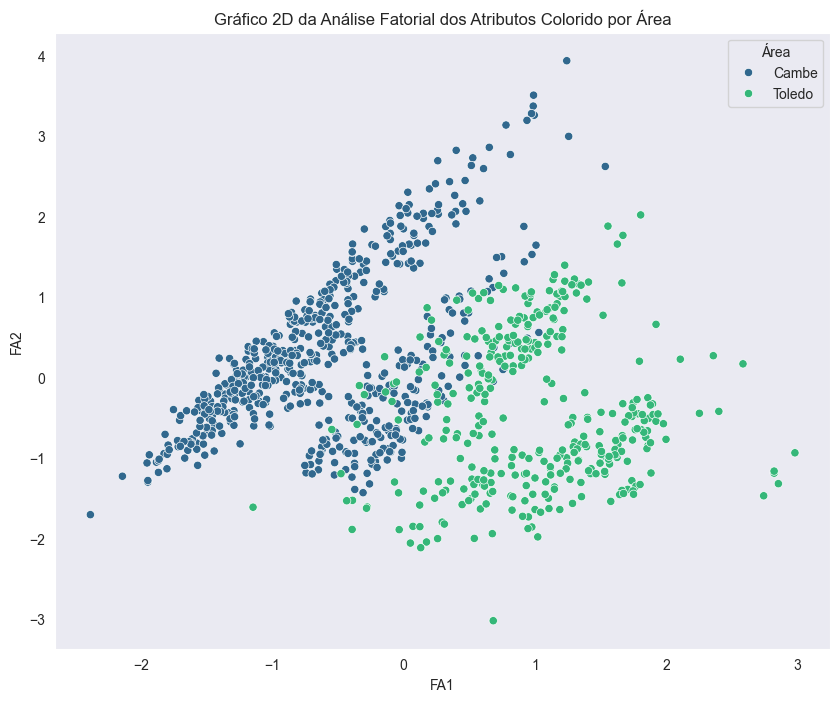

In [15]:
X = df_xrf[spectral_features].to_numpy()
X_scaled = StandardScaler().fit_transform(X)

# Realiza a Análise Fatorial nos atributos espectrais
fa_results = FactorAnalysis(n_components=2)
fa_result = fa_results.fit_transform(X_scaled)

# Cria um DataFrame com os resultados da Análise Fatorial
fa_df = pd.DataFrame(fa_result, columns=['FA1', 'FA2'], index=df_xrf.index)

# Gera o gráfico 2D da Análise Fatorial
plt.figure(figsize=(10, 8))
sns.scatterplot(data=fa_df, x='FA1', y='FA2', hue=fa_df.index, palette='viridis')
plt.title('Gráfico 2D da Análise Fatorial dos Atributos Colorido por Área')
plt.legend(title='Área')
plt.show()
plt.close()